In [ ]:
from pathlib import Path

DATA_DIR  = Path('path_to_preprocessed_data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'

In [ ]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed
from plots import plot_f1_training_curves, build_summary_df, plot_summary_table, plot_metrics_comparison, plot_confusion_matrix, plot_loss_and_f1_curves
EXPERIMENT_PATH = os.path.join(REPO_PATH, 'experiments/transformer_architecture')
sys.path.insert(0, EXPERIMENT_PATH)
from embeddings_plots import extract_embeddings, get_best_model, plot_tsne_comparison
from pooling_plots import extract_attention_weights, plot_attention_heatmap_comparison, plot_attention_profiles

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cuda


In [9]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
LR = 3e-4
REPR = 'mfcc'
D_MODEL = 128 
POOLING_OPTIONS = ['mean', 'attention_pooling_linear', 'attention_pooling_sequential']
CLASS_NAMES = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go','unknown', 'silence']

In [10]:
train_ds, valid_ds, test_ds = get_datasets(data_format=REPR, train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
precompute_features(train_ds, Path('/kaggle/working/cache/train_mfcc'))
precompute_features(valid_ds, Path('/kaggle/working/cache/valid_mfcc'))
precompute_features(test_ds,  Path('/kaggle/working/cache/test_mfcc'))

train_cached = CachedDataset('/kaggle/working/cache/train_mfcc')
valid_cached = CachedDataset('/kaggle/working/cache/valid_mfcc')
test_cached  = CachedDataset('/kaggle/working/cache/test_mfcc')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train_mfcc


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid_mfcc


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test_mfcc


In [11]:
def run_pooling_experiment(model_factory, pooling_options, seeds, epochs=EPOCHS,
                           batch_size=BATCH_SIZE, lr=LR, device=device, model_name='Model'):
    """
    Trains and evaluates model_factory(pooling) for each pooling option and seed.

    Args:
        model_factory: callable(pooling_str) -> nn.Module, should return a model configured for that pooling type. CNN (which has no pooling param) can ignore the arg.
        pooling_options: list of str, e.g. ['mean', 'attention_pooling_linear', ...]
        seeds: list of int
        ...

    Returns:
        results[pooling][seed] = {
            'history', 'valid_acc', 'valid_loss', 'valid_f1',
            'test_acc', 'test_macro_f1', 'test_weighted_f1', 'test_cm', 'model'
        }
    """
    results = {}

    for pooling in pooling_options:
        results[pooling] = {}
        for seed in seeds:
            print(f'\n[{model_name}] pooling={pooling} | seed={seed}')
            print('-' * 55)
            set_seed(seed)

            model = model_factory(pooling).to(device)
            model, history = train(model, train_cached, valid_cached, epochs=epochs, batch_size=batch_size, lr=lr, device=str(device),
                                   verbose=True, verbose_interval=5)

            preds, labels = predict(model, test_cached, device=str(device), batch_size=batch_size)
            test_results = evaluate(preds, labels, print_report=False)

            results[pooling][seed] = {
                'history': history,
                'valid_acc': history['valid_acc'][-1],
                'valid_loss': history['valid_loss'][-1],
                'valid_f1': history['valid_f1'][-1],
                'test_acc': test_results['acc'],
                'test_macro_f1': test_results['macro_f1'],
                'test_weighted_f1': test_results['weighted_f1'],
                'test_cm': test_results['cm'],
                'model': model,
            }

    return results

In [12]:
POOLING_OPTIONS = ['mean', 'attention_pooling_linear', 'attention_pooling_sequential']

def transformer_factory(pooling):
    return Transformer(n_features=40, n_timesteps=101, num_classes=12, d_model=128, nhead=4, num_layers=4, dropout=0.1, pooling=pooling)

def cnn_transformer_factory(pooling):
    return CNNTransformer(n_features=40, n_timesteps=101, num_classes=12, base_channels=32, d_model=128, nhead=4, num_layers=4, dropout=0.1, pooling=pooling)

In [15]:
transformer_pooling_results = run_pooling_experiment(model_factory=transformer_factory, pooling_options=POOLING_OPTIONS,
    seeds=SEEDS, model_name='Transformer')


[Transformer] pooling=mean | seed=0
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1423 | Valid Loss: 0.2101 | Valid Acc: 0.9329 | Valid Macro F1: 0.8917
Epoch 10/30 | Train Loss: 0.0697 | Valid Loss: 0.1984 | Valid Acc: 0.9461 | Valid Macro F1: 0.9200
Epoch 15/30 | Train Loss: 0.0432 | Valid Loss: 0.1972 | Valid Acc: 0.9501 | Valid Macro F1: 0.9249
Epoch 20/30 | Train Loss: 0.0226 | Valid Loss: 0.2176 | Valid Acc: 0.9547 | Valid Macro F1: 0.9332
Epoch 25/30 | Train Loss: 0.0132 | Valid Loss: 0.2420 | Valid Acc: 0.9531 | Valid Macro F1: 0.9300
Epoch 30/30 | Train Loss: 0.0098 | Valid Loss: 0.2412 | Valid Acc: 0.9547 | Valid Macro F1: 0.9319
Best validation accuracy: 0.9588

[Transformer] pooling=mean | seed=1
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1431 | Valid Loss: 0.1929 | Valid Acc: 0.9445 | Valid Macro F1: 0.9177
Epoch 10/30 | Train Loss: 0.0741 | Valid Loss: 0.1933 | Valid Acc: 0.9464 | Valid Macro F1

In [16]:
cnn_transformer_pooling_results = run_pooling_experiment(model_factory=cnn_transformer_factory, pooling_options=POOLING_OPTIONS,
    seeds=SEEDS, model_name='CNNTransformer')


[CNNTransformer] pooling=mean | seed=0
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1069 | Valid Loss: 0.1656 | Valid Acc: 0.9495 | Valid Macro F1: 0.9203
Epoch 10/30 | Train Loss: 0.0606 | Valid Loss: 0.1730 | Valid Acc: 0.9515 | Valid Macro F1: 0.9284
Epoch 15/30 | Train Loss: 0.0346 | Valid Loss: 0.1653 | Valid Acc: 0.9610 | Valid Macro F1: 0.9417
Epoch 20/30 | Train Loss: 0.0185 | Valid Loss: 0.1891 | Valid Acc: 0.9613 | Valid Macro F1: 0.9425
Epoch 25/30 | Train Loss: 0.0061 | Valid Loss: 0.2229 | Valid Acc: 0.9605 | Valid Macro F1: 0.9419
Epoch 30/30 | Train Loss: 0.0020 | Valid Loss: 0.2384 | Valid Acc: 0.9605 | Valid Macro F1: 0.9414
Best validation accuracy: 0.9616

[CNNTransformer] pooling=mean | seed=1
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1091 | Valid Loss: 0.1866 | Valid Acc: 0.9452 | Valid Macro F1: 0.9198
Epoch 10/30 | Train Loss: 0.0561 | Valid Loss: 0.1648 | Valid Acc: 0.9571 | Valid Ma

### Transformer results

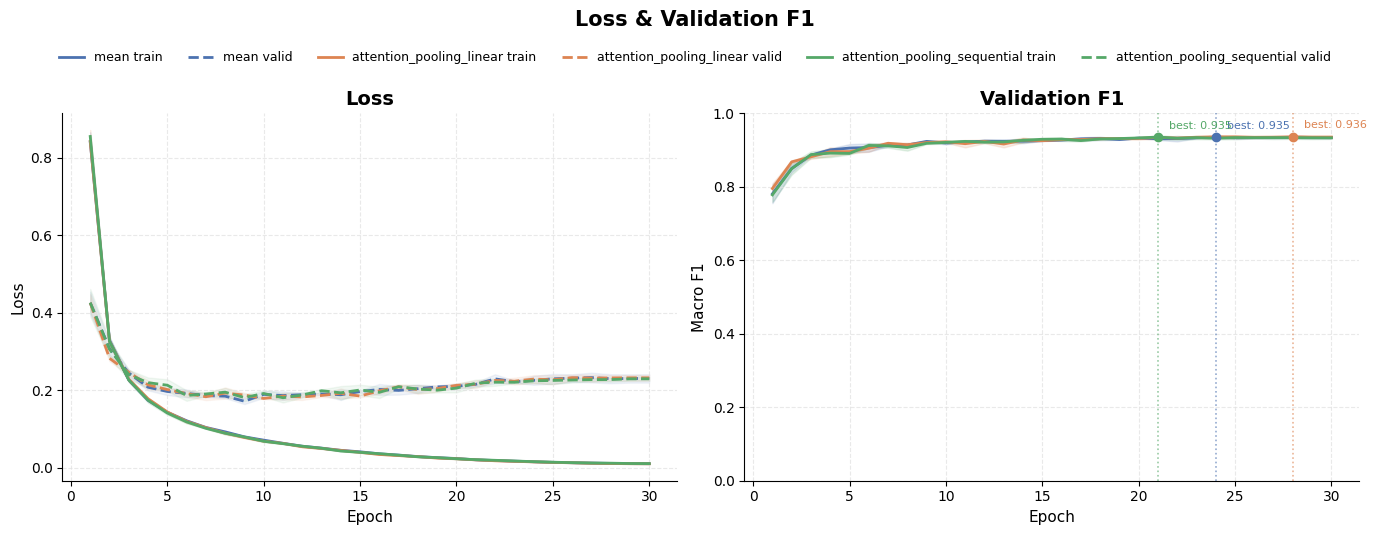

In [18]:
plot_loss_and_f1_curves(transformer_pooling_results, group_name='')

In [19]:
summary_df = build_summary_df({
    f'pooling={p}': {'mfcc': v}
    for p, v in transformer_pooling_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
1,pooling=attention_pooling_linear,mfcc,0.9587 ± 0.0018,0.002,0.9089 ± 0.0032,0.003,0.9601 ± 0.0018,0.002
2,pooling=attention_pooling_sequential,mfcc,0.9586 ± 0.0018,0.002,0.9102 ± 0.0034,0.004,0.9595 ± 0.0017,0.002


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
1,pooling=attention_pooling_linear,mfcc,0.9587 ± 0.0018,0.002,0.9089 ± 0.0032,0.003,0.9601 ± 0.0018,0.002
2,pooling=attention_pooling_sequential,mfcc,0.9586 ± 0.0018,0.002,0.9102 ± 0.0034,0.004,0.9595 ± 0.0017,0.002


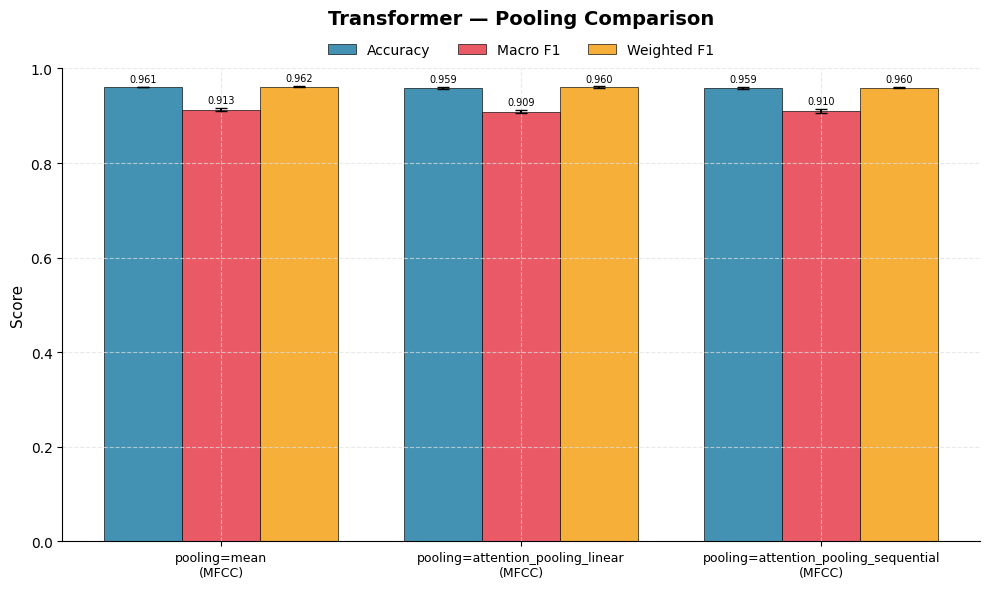

In [27]:
plot_metrics_comparison(summary_df, title='Transformer — Pooling Comparison')

In [28]:
embeddings_per_pooling = {}
for pooling in POOLING_OPTIONS:
    print(f'Extracting embeddings for pooling={pooling}...')
    model = get_best_model(transformer_pooling_results, pooling)
    embeddings, labels = extract_embeddings(model, test_cached, device)
    embeddings_per_pooling[pooling] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for pooling=mean...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_linear...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_sequential...
  -> shape: (6865, 128)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


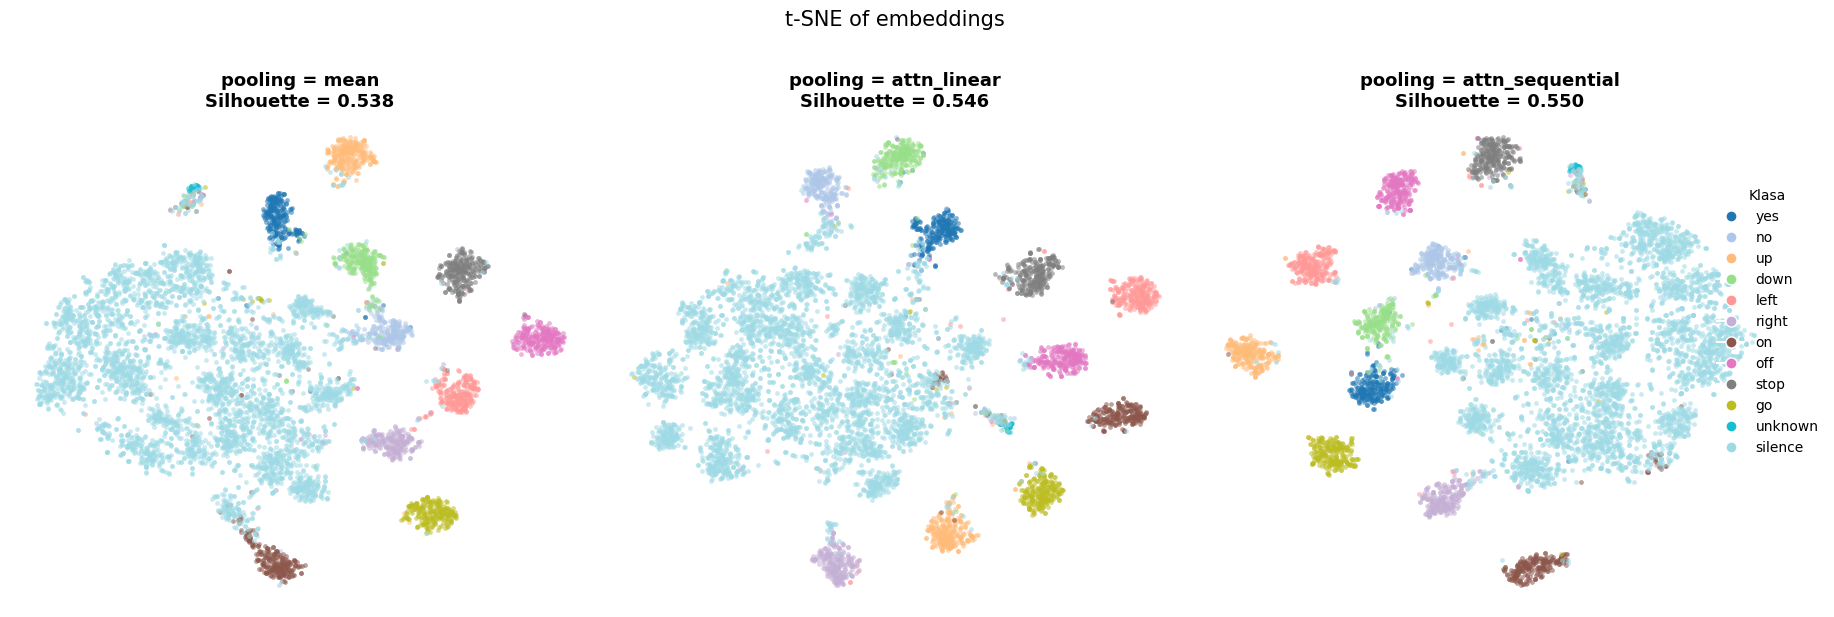

In [29]:
plot_tsne_comparison(embeddings_per_pooling, CLASS_NAMES, key_label='pooling')

In [30]:
ATTENTION_POOLINGS = ['attention_pooling_linear', 'attention_pooling_sequential']

attn_weights_per_pooling = {}
for pooling in ATTENTION_POOLINGS:
    print(f'Extracting attention weights for pooling={pooling}...')
    model = get_best_model(transformer_pooling_results, pooling)
    weights, labels = extract_attention_weights(model, test_cached, device)
    attn_weights_per_pooling[pooling] = {'weights': weights, 'labels': labels}
    print(f'  -> shape: {weights.shape}')

Extracting attention weights for pooling=attention_pooling_linear...
  -> shape: (6865, 101)
Extracting attention weights for pooling=attention_pooling_sequential...
  -> shape: (6865, 101)


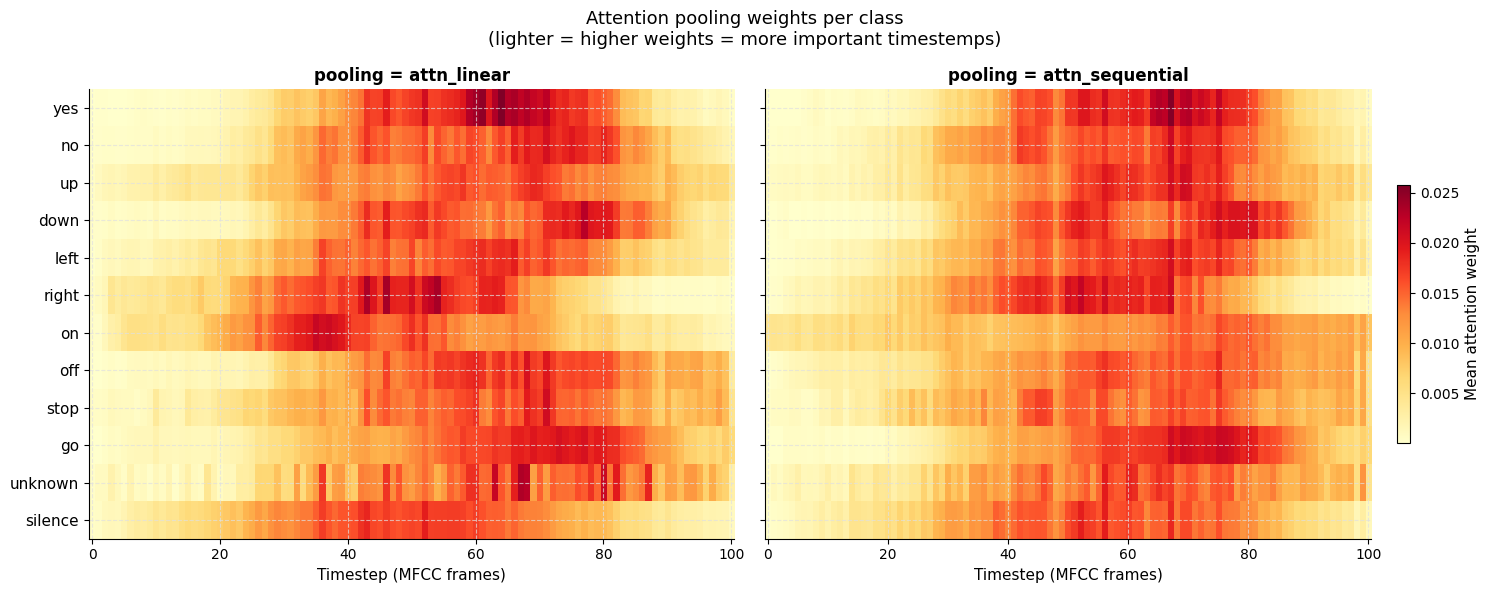

In [31]:
plot_attention_heatmap_comparison(attn_weights_per_pooling, CLASS_NAMES)

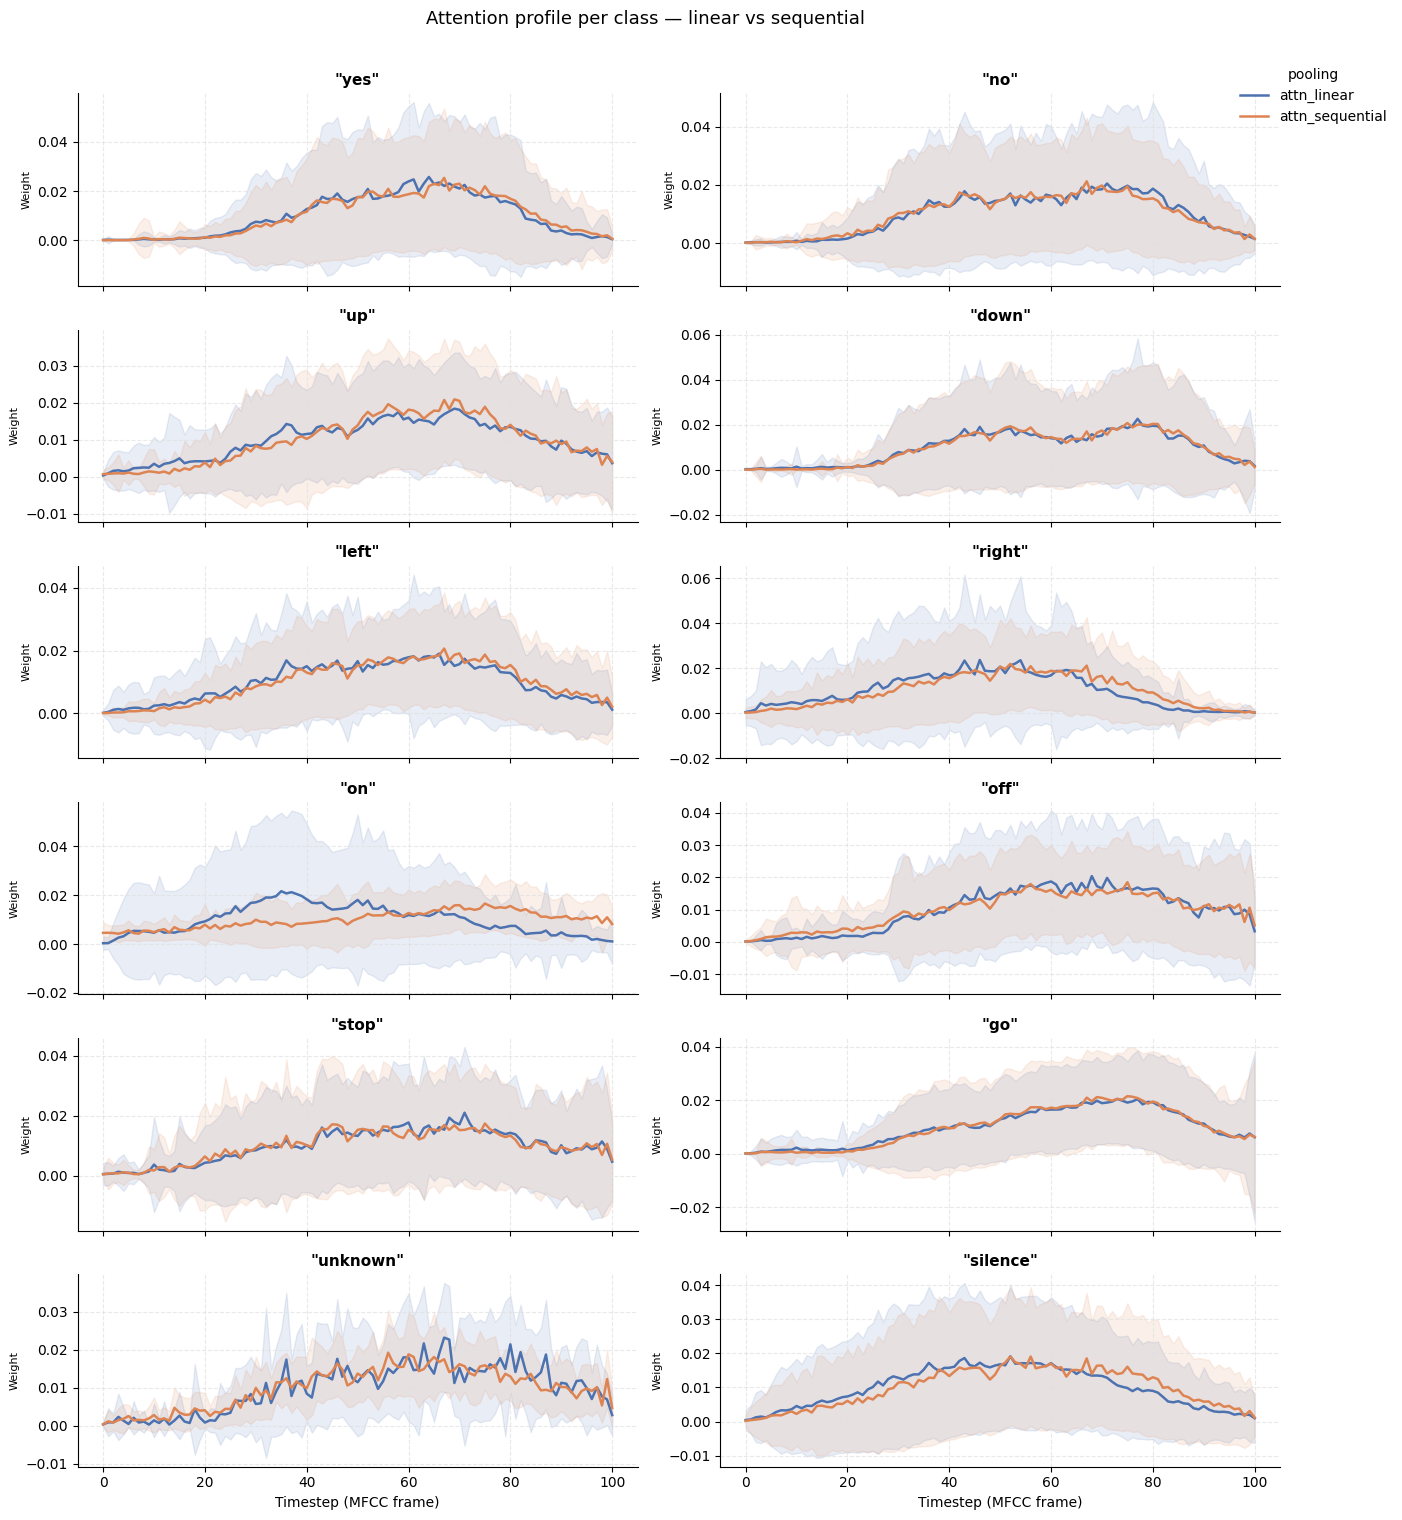

In [32]:
plot_attention_profiles(attn_weights_per_pooling, CLASS_NAMES)


pooling=mean, seed=1, F1=0.9152


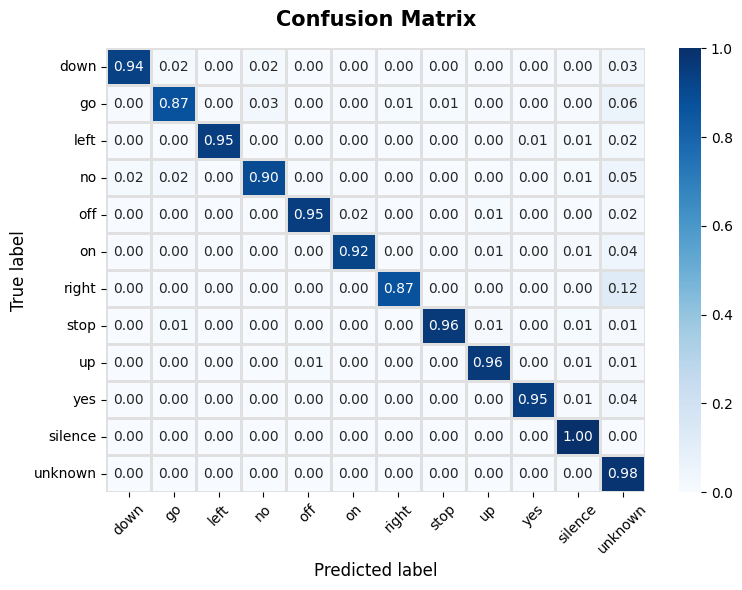


pooling=attn_linear, seed=0, F1=0.9131


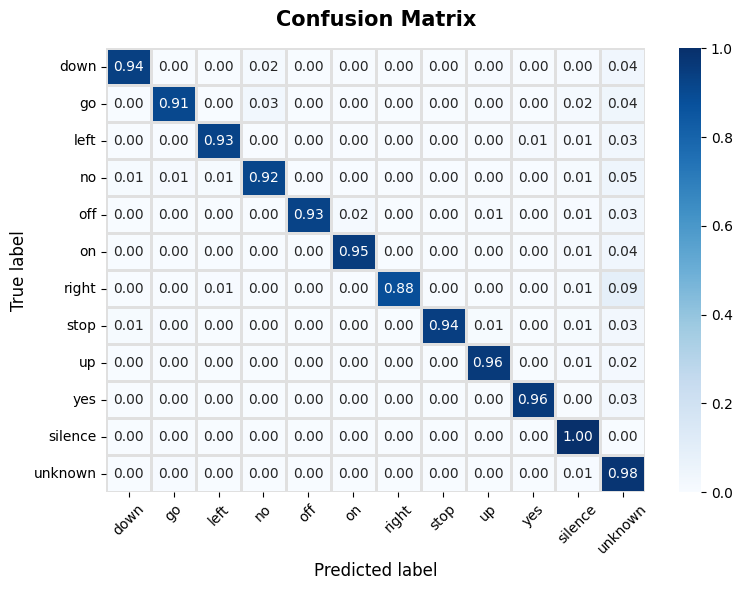


pooling=attn_sequential, seed=1, F1=0.9149


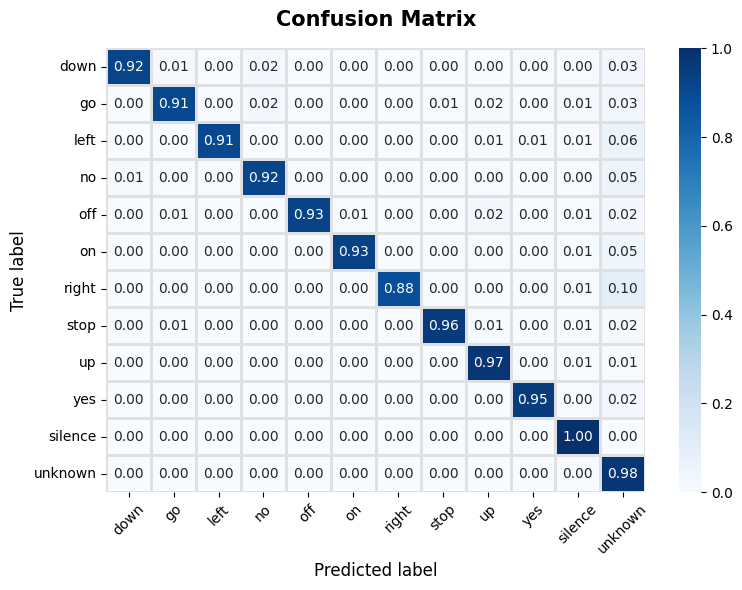

In [34]:
for pooling in POOLING_OPTIONS:
    best_seed = max(transformer_pooling_results[pooling], key=lambda s: transformer_pooling_results[pooling][s]['test_macro_f1'])
    best_result = transformer_pooling_results[pooling][best_seed]
    short = pooling.replace('attention_pooling_', 'attn_')
    print(f'\npooling={short}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])

### CNN Transformer

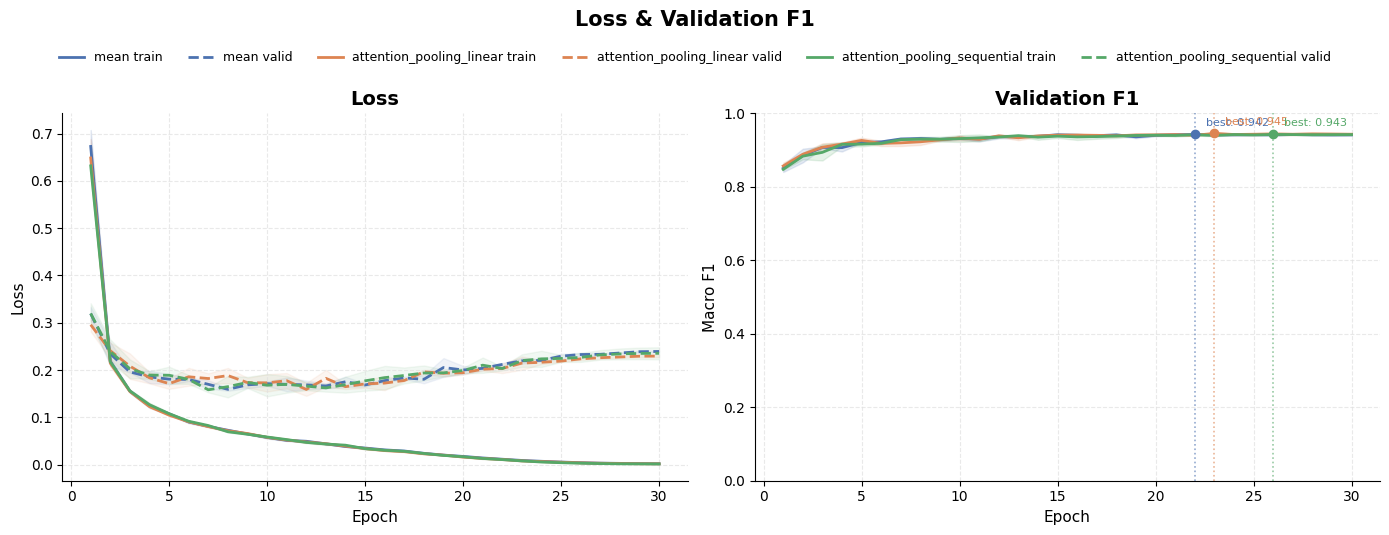

In [35]:
plot_loss_and_f1_curves(cnn_transformer_pooling_results, group_name='')

In [36]:
summary_df = build_summary_df({
    f'pooling={p}': {'mfcc': v}
    for p, v in cnn_transformer_pooling_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,pooling=attention_pooling_linear,mfcc,0.9699 ± 0.0004,0.000,0.9553 ± 0.0015,0.002,0.9698 ± 0.0004,0.000
2,pooling=attention_pooling_sequential,mfcc,0.9695 ± 0.0019,0.002,0.9554 ± 0.0025,0.003,0.9694 ± 0.0020,0.002


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,pooling=attention_pooling_linear,mfcc,0.9699 ± 0.0004,0.000,0.9553 ± 0.0015,0.002,0.9698 ± 0.0004,0.000
2,pooling=attention_pooling_sequential,mfcc,0.9695 ± 0.0019,0.002,0.9554 ± 0.0025,0.003,0.9694 ± 0.0020,0.002


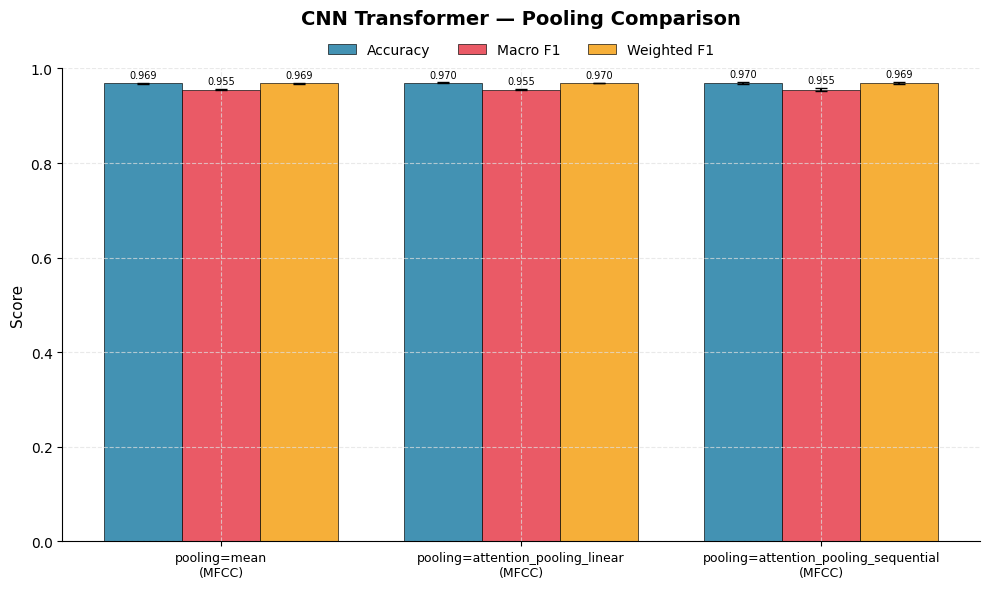

In [37]:
plot_metrics_comparison(summary_df, title='CNN Transformer — Pooling Comparison')

In [41]:
embeddings_per_pooling = {}
for pooling in POOLING_OPTIONS:
    print(f'Extracting embeddings for pooling={pooling}...')
    model = get_best_model(cnn_transformer_pooling_results, pooling)
    embeddings, labels = extract_embeddings_cnn_transformer(model, test_cached, device)
    embeddings_per_pooling[pooling] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for pooling=mean...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_linear...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_sequential...
  -> shape: (6865, 128)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


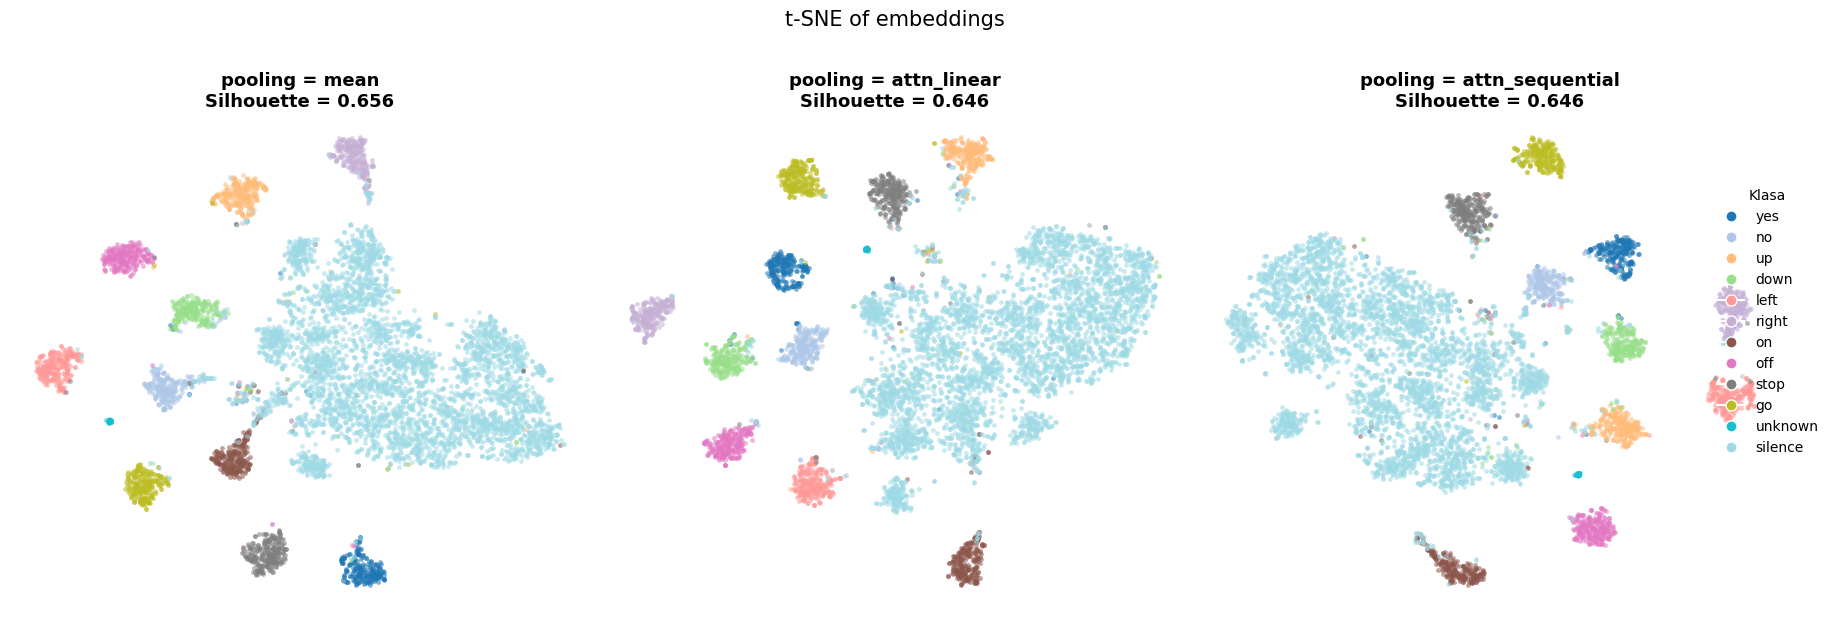

In [42]:
plot_tsne_comparison(embeddings_per_pooling, CLASS_NAMES, key_label='pooling')

In [44]:
ATTENTION_POOLINGS = ['attention_pooling_linear', 'attention_pooling_sequential']

attn_weights_per_pooling = {}
for pooling in ATTENTION_POOLINGS:
    print(f'Extracting attention weights for pooling={pooling}...')
    model = get_best_model(cnn_transformer_pooling_results, pooling)
    weights, labels = extract_attention_weights_cnn_transformer(model, test_cached, device)
    attn_weights_per_pooling[pooling] = {'weights': weights, 'labels': labels}
    print(f'  -> shape: {weights.shape}')

Extracting attention weights for pooling=attention_pooling_linear...
  -> shape: (6865, 12)
Extracting attention weights for pooling=attention_pooling_sequential...
  -> shape: (6865, 12)


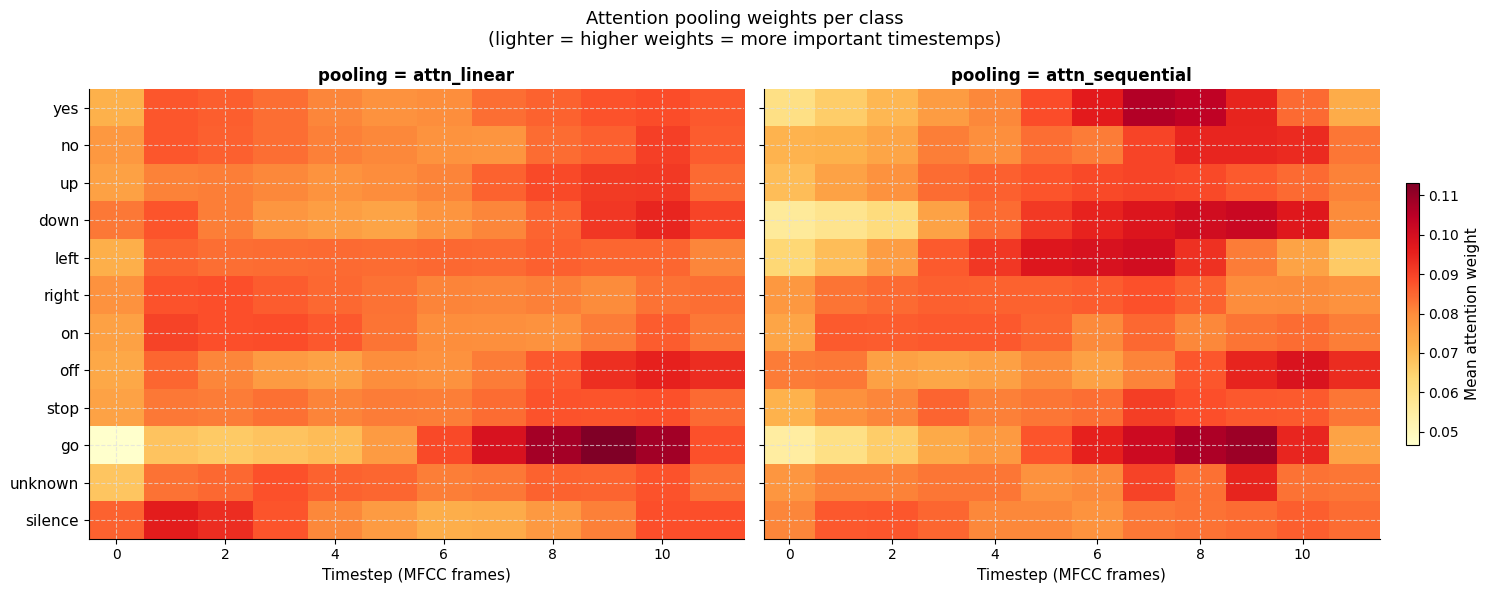

In [45]:
plot_attention_heatmap_comparison(attn_weights_per_pooling, CLASS_NAMES)

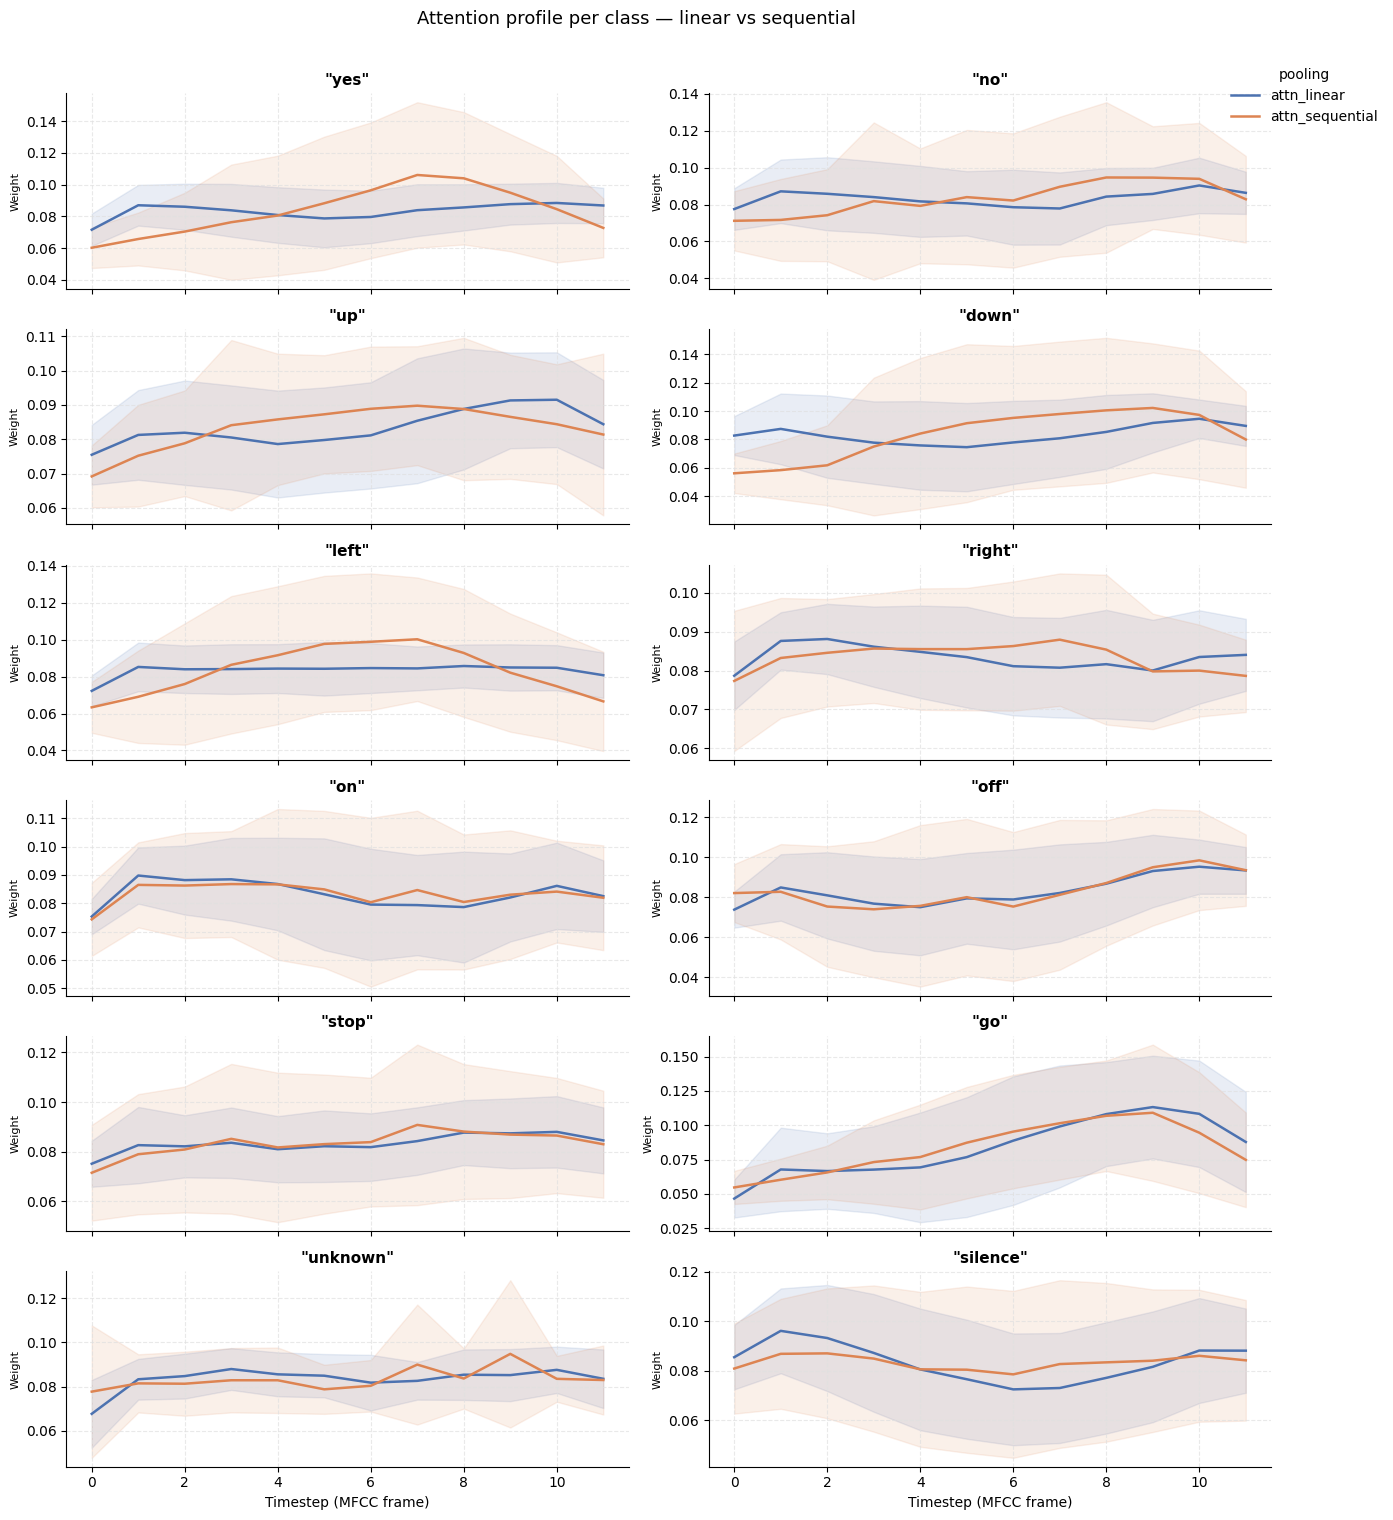

In [46]:
plot_attention_profiles(attn_weights_per_pooling, CLASS_NAMES)


pooling=mean, seed=2, F1=0.9566


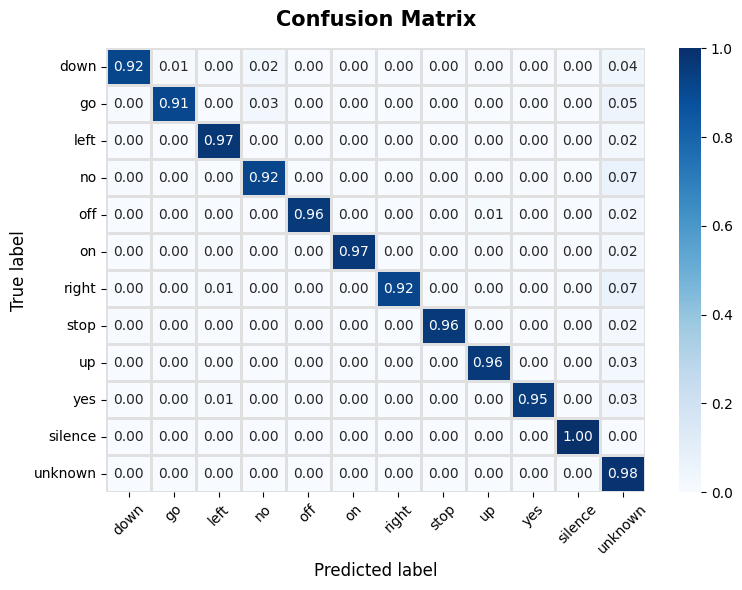


pooling=attn_linear, seed=2, F1=0.9572


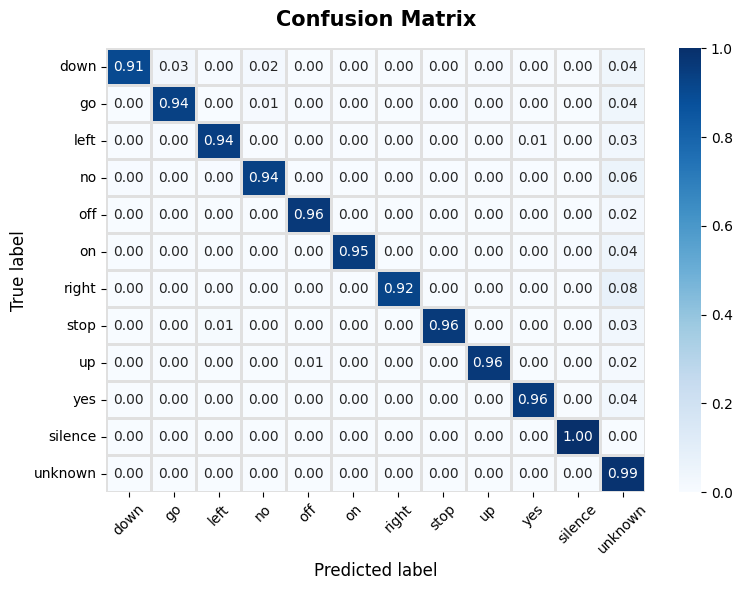


pooling=attn_sequential, seed=2, F1=0.9585


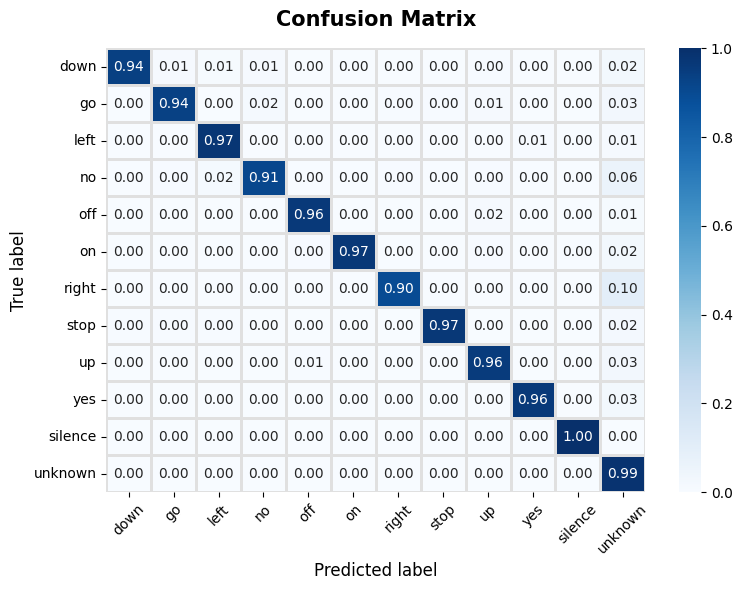

In [47]:
for pooling in POOLING_OPTIONS:
    best_seed = max(cnn_transformer_pooling_results[pooling], key=lambda s: cnn_transformer_pooling_results[pooling][s]['test_macro_f1'])
    best_result = cnn_transformer_pooling_results[pooling][best_seed]
    short = pooling.replace('attention_pooling_', 'attn_')
    print(f'\npooling={short}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])